# Phase 2 — Da planilha de charts a um grafo temporal que alimenta uma GNN

Projeto: **BraSNAM 2026** — GNN temporal heterogêneo para difusão de popularidade musical (Oliveira et al. 2025).

Esta apresentação é **visual** e foca em **como o grafo é construído** a partir dos dados reais,
e como essa estrutura alimenta o modelo temporal da Phase 2.

**Roteiro:**

1. Motivação + esquema do grafo (3 nós, 4 arestas)
2. Contagens reais de nós e arestas
3. **Como cada aresta nasce** — uma visualização por tipo de aresta
4. **Subgrafo real** amostrado dos dados (networkx)
5. **O tempo entra no grafo** — crescimento de arestas por semana, sem vazamento
6. **Do snapshot ao alvo** — agregação semanal, janela causal, splits temporais
7. **A arquitetura, visual** — snapshot → HeteroSAGE → banco de embeddings → GRU → ŷ
8. Resultados preliminares (grid em execução)

> Tudo carrega os **artefatos persistidos** (`hetero_full.pt`, `node_id_map.json`,
> `timeseries.parquet`) — o grafo **não** é reconstruído ao vivo.

## 0. Setup — imports e carregamento dos artefatos

In [1]:
import json, sys
from pathlib import Path

# ROOT robusto: sobe até achar o artefato do grafo
ROOT = Path.cwd()
while not (ROOT / "data" / "processed" / "graph" / "hetero_full.pt").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import networkx as nx
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10

GRAPH_DIR = ROOT / "data" / "processed" / "graph"
g = torch.load(GRAPH_DIR / "hetero_full.pt", weights_only=False)
node_id_map = json.loads((GRAPH_DIR / "node_id_map.json").read_text())
ts = pd.read_parquet(ROOT / "data" / "processed" / "timeseries.parquet")
subset = set(json.loads((ROOT / "data" / "processed" / "subset_ids.json").read_text())["viral_intersect_hit"])

# Mapas reversos (idx -> nome legível)
idx_to_song   = {int(i): s for s, i in node_id_map["music"]["spotify_id_to_idx"].items()}
idx_to_artist = {int(i): a for a, i in node_id_map["artist"]["artist_id_to_idx"].items()}
idx_to_genre  = {int(i): gname for gname, i in node_id_map["genre"]["genre_name_to_idx"].items()}

# Paleta por tipo de nó
COL = {"music": "#e8743b", "artist": "#1f9ee0", "genre": "#19a979"}

print(f"Grafo: {g.num_nodes} nós, {sum(g[et].edge_index.shape[1] for et in g.edge_types):,} arestas")
print(f"Subset viral∩hit: {len(subset)} músicas | timeseries: {len(ts):,} linhas diárias")

/home/cristianomendieta/estudos/mestrado/mestrado-roadmap/music-influence-gnn/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Grafo: 8757 nós, 690,405 arestas
Subset viral∩hit: 1981 músicas | timeseries: 4,443,760 linhas diárias


## 0.5 Os dados crus do MGD+ — a planilha *antes* do grafo

Antes de existir qualquer grafo, o MGD+ é um punhado de **planilhas**. Cada linha de um chart é
uma música num dia (com posição e streams); os arquivos de *songs* trazem as **features
acústicas**; *artists* traz o **catálogo BR** (créditos e gêneros de cada artista);
*genre_network* traz a **co-ocorrência de gêneros**. Abaixo, **amostras reais** de cada fonte —
é desse material cru, tabular e desconexo, que o grafo heterogêneo nasce.

In [ ]:
from IPython.display import display
RAW = ROOT / "data"

def peek(title, df, cols=None, n=4):
    print(f"\n{'─'*78}\n▸ {title}   —   shape real {df.shape}\n{'─'*78}")
    display(df[cols].head(n) if cols else df.head(n))

# Charts: tab-separated; songs/artists: tab-separated; genre_network: VÍRGULA (não tab!)
charts_top = pd.read_csv(RAW / "charts/mgdplus/spotify_charts_regional_br.csv", sep="\t")
charts_vir = pd.read_csv(RAW / "charts/mgdplus/spotify_charts_viral_br.csv", sep="\t")
songs19    = pd.read_csv(RAW / "songs/br-hit_songs-2019.csv", sep="\t")
artists    = pd.read_csv(RAW / "artists/br-artists-all_time.csv", sep="\t")
genres19   = pd.read_csv(RAW / "genre_network/br-genre_network-2019.csv")  # sep=','

peek("CHARTS · Top 200 (spotify_charts_regional_br) — música × dia × posição", charts_top,
     ["ID", "Track", "Artist", "Position", "Streams", "Date", "Chart"])
peek("CHARTS · Viral 50 (spotify_charts_viral_br) — sem streams, só posição", charts_vir,
     ["ID", "Track", "Artist", "Position", "Date", "Chart"])
peek("SONGS · features acústicas (br-hit_songs-2019) — 1 linha por música", songs19,
     ["song_id", "song_name", "artist_name", "popularity", "explicit",
      "danceability", "energy", "valence", "tempo"])
peek("ARTISTS · catálogo BR (br-artists-all_time) — créditos + gêneros", artists,
     ["artist_id", "name", "genres", "years_on_charts", "num_hits", "num_collab_hits"])
peek("GENRE NETWORK · co-ocorrência (br-genre_network-2019) — par de gêneros + peso", genres19,
     ["Source", "Target", "Weight", "Avg_Popularity"])

**De planilha a grafo — o mapa da transformação.** Cada coluna dessas tabelas cruas vira um
pedaço do grafo heterogêneo. É essa releitura relacional que as próximas seções detalham:

| Planilha crua (MGD+) | Vira no grafo… | Como |
|---|---|---|
| `charts/*` — música × dia × posição | **nós `music`** + arestas **`cotrajectory`** | músicas viram nós; coexistir ≥7 dias num chart vira aresta dirigida (quem entrou antes → depois) |
| `songs/br-hit_songs-*` — features acústicas | **features dos nós `music`** (15-d) | 9 acústicas (z-score) + popularidade + explicit + tipo + streams + dias no chart |
| `artists/br-artists-all_time` — créditos + `genres` | **nós `artist`** + arestas **`performs`** / **`has_genre`** | crédito da música → `performs` (pos 0 = main, demais = feat); coluna `genres` → `has_genre` |
| `genre_network/*` — `Source,Target,Weight` | **arestas `cooccurs`** entre nós `genre` | cada linha é um par de gêneros co-ocorrentes; simétrica por construção |
| coluna `Date` dos charts | **`first_seen_week ∈ [0,260]`** em toda aresta | ISO-week desde 2017-W1 → define em que snapshot a aresta aparece |

> Repare no salto conceitual: a planilha é **plana e isolada** (uma linha não "conhece" a
> outra); o grafo torna **explícitas as relações** que estavam apenas implícitas nas
> tabelas — exatamente o sinal que a hipótese do projeto quer explorar.

## 1. O esquema, visual

Três tipos de nó e quatro relações (mais a reversa `rev_has_genre`). A intuição: a
popularidade de uma música não vive isolada — ela depende de **quem a canta** (`performs`),
**a que gêneros** esse artista pertence (`has_genre`), **quais músicas dividem o chart com ela**
(`cotrajectory`) e **como os gêneros se relacionam** (`cooccurs`).

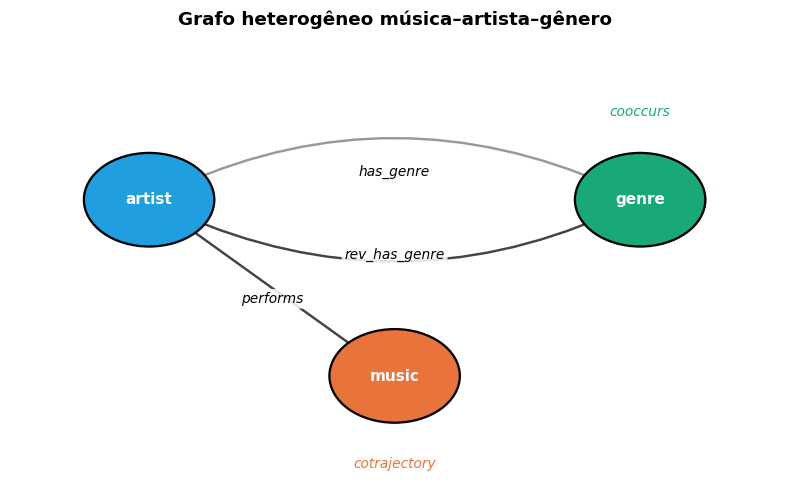

In [2]:
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.axis("off")
pos = {"artist": (0.18, 0.5), "music": (0.5, 0.18), "genre": (0.82, 0.5)}
for name, (x, y) in pos.items():
    ax.add_patch(plt.Circle((x, y), 0.085, color=COL[name], zorder=3, ec="black", lw=1.5))
    ax.text(x, y, name, ha="center", va="center", color="white", fontweight="bold", zorder=4)

def arrow(a, b, label, rad, dy=0.0, color="#444"):
    xa, ya = pos[a]; xb, yb = pos[b]
    ar = FancyArrowPatch((xa, ya), (xb, yb), connectionstyle=f"arc3,rad={rad}",
                         arrowstyle="-|>", mutation_scale=16, lw=1.6, color=color, zorder=2,
                         shrinkA=22, shrinkB=22)
    ax.add_patch(ar)
    mx, my = (xa + xb) / 2, (ya + yb) / 2 + dy
    ax.text(mx, my, label, ha="center", va="center", fontsize=9, style="italic",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85))

arrow("artist", "music", "performs", 0.0, dy=-0.02)
arrow("artist", "genre", "has_genre", 0.25, dy=0.05)
arrow("genre", "artist", "rev_has_genre", 0.25, dy=-0.10, color="#999")
# self loops
for n, lab, off in [("music", "cotrajectory", (0.0, -0.16)), ("genre", "cooccurs", (0.0, 0.16))]:
    x, y = pos[n]
    ax.add_patch(FancyArrowPatch((x-0.05, y+off[1]*0.4), (x+0.05, y+off[1]*0.4),
                 connectionstyle=f"arc3,rad={1.8 if off[1]>0 else -1.8}", arrowstyle="-|>",
                 mutation_scale=14, lw=1.6, color=COL[n], zorder=2))
    ax.text(x, y + off[1], lab, ha="center", va="center", fontsize=9, style="italic", color=COL[n])
ax.set_xlim(0, 1); ax.set_ylim(0, 0.8)
ax.set_title("Grafo heterogêneo música–artista–gênero", fontweight="bold")
plt.show()

## 2. Contagens reais de nós e arestas

In [3]:
def et_str(et): return f"{et[0]} → {et[1]} → {et[2]}"
print("NÓS")
for nt in g.node_types:
    print(f"  {nt:7s}  {g[nt].num_nodes:>6,}   features {tuple(g[nt].x.shape)}")
print("\nARESTAS")
rows = []
for et in g.edge_types:
    s = g[et]
    attr = tuple(s.edge_attr.shape) if getattr(s, 'edge_attr', None) is not None else "—"
    rows.append({"aresta": et_str(et), "# arestas": s.edge_index.shape[1], "edge_attr": str(attr)})
pd.DataFrame(rows)

NÓS
  music     6,526   features (6526, 15)
  artist    1,701   features (1701, 4)
  genre       530   features (530, 32)

ARESTAS


,aresta,# arestas,edge_attr
0,artist → performs → music,9274,"(9274, 3)"
1,artist → has_genre → genre,3344,—
2,genre → rev_has_genre → artist,3344,—
3,music → cotrajectory → music,664577,"(664577, 4)"
4,genre → cooccurs → genre,9866,"(9866, 4)"


## 3. Como cada aresta nasce

A seguir, **uma visualização por tipo de aresta**, todas a partir dos atributos reais
guardados no grafo.

### 3a. `performs` (artista → música)

Vem da lista de créditos de cada música (`songs_df.artist_id`). A **posição 0** é o artista
principal (papel *main*); os demais são *feat*. O atributo guarda `[role, posição, first_seen_week]`.

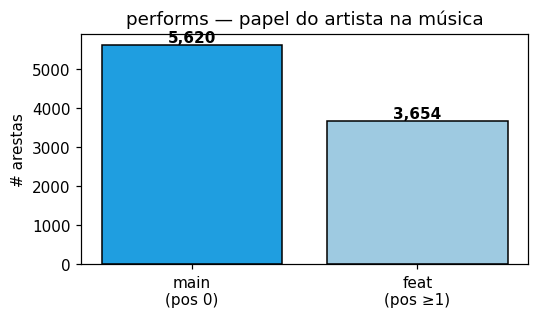

In [4]:
perf = g[("artist", "performs", "music")]
role = perf.edge_attr[:, 0].numpy()  # 0=main, 1=feat
fig, ax = plt.subplots(figsize=(5, 3))
counts = [(role == 0).sum(), (role == 1).sum()]
ax.bar(["main\n(pos 0)", "feat\n(pos ≥1)"], counts, color=[COL["artist"], "#9ecae1"], ec="black")
for i, c in enumerate(counts):
    ax.text(i, c, f"{c:,}", ha="center", va="bottom", fontweight="bold")
ax.set_title("performs — papel do artista na música"); ax.set_ylabel("# arestas")
plt.tight_layout(); plt.show()

### 3b. `has_genre` (artista → gênero) + reversa

Filiação de gênero do artista. Como não há informação temporal sobre *quando* o artista
passou a pertencer ao gênero, `first_seen_week = 0` (a aresta existe desde a semana 0). A
reversa `rev_has_genre` é adicionada via `ToUndirected` para o *message passing* fluir nos
dois sentidos.

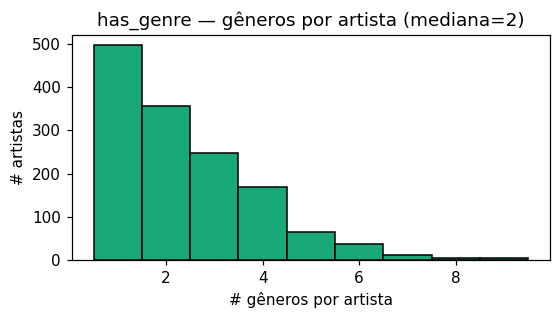

In [5]:
hg = g[("artist", "has_genre", "genre")]
out_deg = np.bincount(hg.edge_index[0].numpy(), minlength=g["artist"].num_nodes)
out_deg = out_deg[out_deg > 0]
fig, ax = plt.subplots(figsize=(5.2, 3))
ax.hist(out_deg, bins=range(1, out_deg.max() + 2), color=COL["genre"], ec="black", align="left")
ax.set_xlabel("# gêneros por artista"); ax.set_ylabel("# artistas")
ax.set_title(f"has_genre — gêneros por artista (mediana={int(np.median(out_deg))})")
plt.tight_layout(); plt.show()

### 3c. `cotrajectory` (música → música) — a aresta mais rica

Duas músicas que **coexistem ≥ 7 dias no mesmo chart** viram uma aresta. A **direção** é dada
por quem entrou no chart primeiro. Atributos: `[dias juntos, dist. média de posição, chart, first_seen_week]`.

**Passo a passo — de duas curvas no chart a uma aresta:**

```
 chart (Top200/Viral50)        dia 1  2  3  4  5  6  7  8 ...
 ────────────────────────────────────────────────────────────
 música A  (entrou antes)   ●  ●  ●  ●  ●  ●  ●  ●  ●         ← entra primeiro
 música B  (entrou depois)         ●  ●  ●  ●  ●  ●  ●  ●     ← entra depois
                                   └──── ≥ 7 dias juntos ────┘
                                              │
                                              ▼
                              aresta   A ──cotrajectory──► B
                              attr = [dias_juntos, Δposição_média, chart, semana]
```

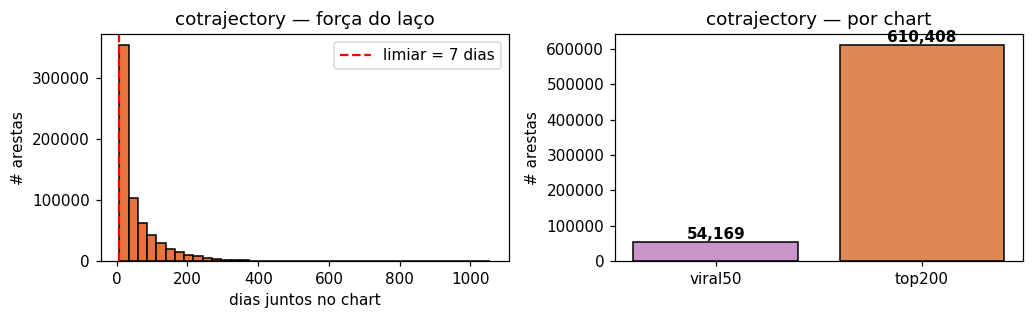

In [6]:
cot = g[("music", "cotrajectory", "music")]
days = cot.edge_attr[:, 0].numpy()
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3))
ax[0].hist(days, bins=40, color=COL["music"], ec="black")
ax[0].axvline(7, color="red", ls="--", label="limiar = 7 dias")
ax[0].set_xlabel("dias juntos no chart"); ax[0].set_ylabel("# arestas"); ax[0].legend()
ax[0].set_title("cotrajectory — força do laço")
chart = cot.edge_attr[:, 2].numpy()
cc = [(chart == 0).sum(), (chart == 1).sum()]
ax[1].bar(["viral50", "top200"], cc, color=["#c994c7", "#dd8855"], ec="black")
for i, c in enumerate(cc): ax[1].text(i, c, f"{c:,}", ha="center", va="bottom", fontweight="bold")
ax[1].set_title("cotrajectory — por chart"); ax[1].set_ylabel("# arestas")
plt.tight_layout(); plt.show()

### 3d. `cooccurs` (gênero ↔ gênero)

Rede de co-ocorrência de gêneros do MGD+ (simétrica). O peso da aresta mede a força da
associação entre dois gêneros.

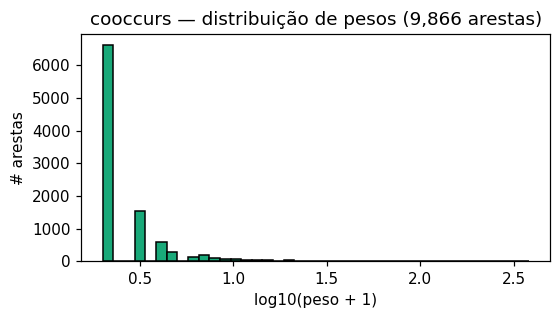

In [7]:
coo = g[("genre", "cooccurs", "genre")]
w = coo.edge_attr[:, 0].numpy()
fig, ax = plt.subplots(figsize=(5.2, 3))
ax.hist(np.log10(w + 1), bins=40, color=COL["genre"], ec="black")
ax.set_xlabel("log10(peso + 1)"); ax.set_ylabel("# arestas")
ax.set_title(f"cooccurs — distribuição de pesos ({coo.edge_index.shape[1]:,} arestas)")
plt.tight_layout(); plt.show()

## 4. Subgrafo real (networkx)

Amostramos a vizinhança **1–2 hop** de uma música real do subset de análise: seus
co-trajetos, o(s) artista(s) que a executam e os gêneros desses artistas. Cores por tipo de nó.

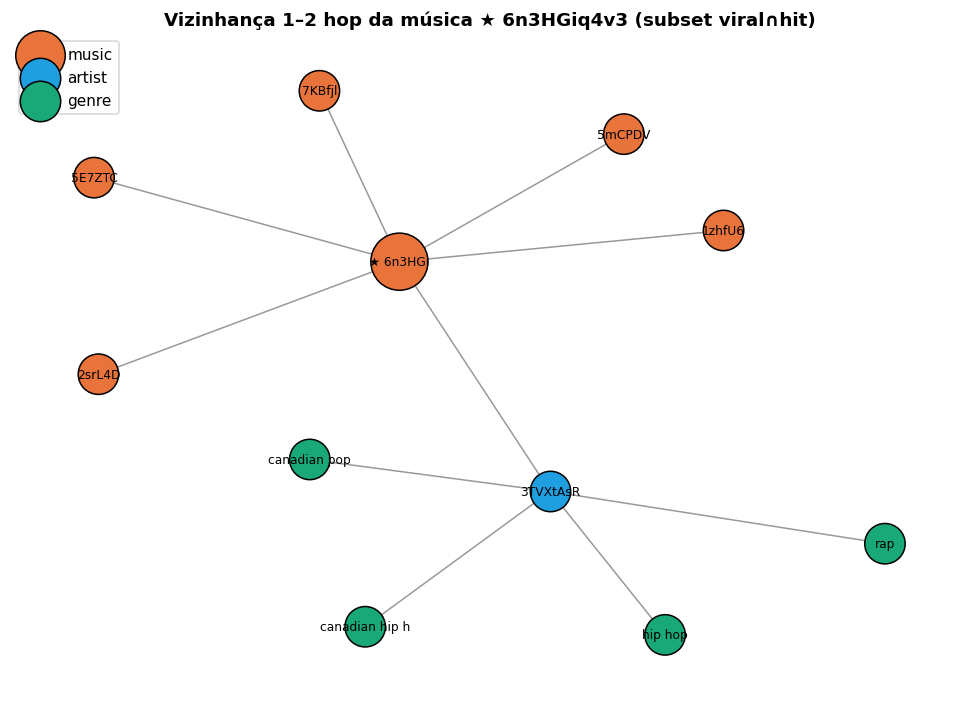

semente idx=5611 | 5 co-trajetos, 1 artista(s), 4 gênero(s)


In [8]:
cot_ei = g[("music", "cotrajectory", "music")].edge_index.numpy()
perf_ei = g[("artist", "performs", "music")].edge_index.numpy()
hg_ei   = g[("artist", "has_genre", "genre")].edge_index.numpy()

# Escolher uma música-semente: do subset, com performs e grau de cotrajetória moderado (bom p/ desenhar)
cot_deg = np.bincount(cot_ei[0], minlength=g["music"].num_nodes) + np.bincount(cot_ei[1], minlength=g["music"].num_nodes)
has_perf = set(perf_ei[1].tolist())
cands = [i for i in range(g["music"].num_nodes)
         if idx_to_song[i] in subset and i in has_perf and 4 <= cot_deg[i] <= 10]
seed = sorted(cands, key=lambda i: cot_deg[i])[0]

K = 6  # limitar vizinhos de cotrajetória desenhados
cot_neigh = list(cot_ei[1][cot_ei[0] == seed]) + list(cot_ei[0][cot_ei[1] == seed])
cot_neigh = list(dict.fromkeys(cot_neigh))[:K]
artists = list(dict.fromkeys(perf_ei[0][perf_ei[1] == seed].tolist()))[:3]
genres = []
for a in artists:
    genres += list(hg_ei[1][hg_ei[0] == a])[:4]
genres = list(dict.fromkeys(genres))[:6]

G = nx.Graph(); types = {}
def add(nid, t): n = f"{t}:{nid}"; types[n] = t; G.add_node(n); return n
s_seed = add(seed, "music")
for m in cot_neigh: G.add_edge(s_seed, add(m, "music"))
for a in artists:
    na = add(a, "artist"); G.add_edge(na, s_seed)
    for gen in hg_ei[1][hg_ei[0] == a][:4]:
        if f"genre:{gen}" in [f"genre:{x}" for x in genres] or len(genres) < 6:
            G.add_edge(na, add(int(gen), "genre"))

lab = {}
for n in G.nodes:
    t, i = n.split(":"); i = int(i)
    if t == "genre": lab[n] = idx_to_genre[i][:14]
    elif t == "artist": lab[n] = idx_to_artist[i][:8]
    else: lab[n] = ("★ " if i == seed else "") + idx_to_song[i][:6]

fig, ax = plt.subplots(figsize=(9, 6.5))
layout = nx.spring_layout(G, seed=42, k=0.9)
nx.draw_networkx_edges(G, layout, alpha=0.4, ax=ax)
for t in COL:
    ns = [n for n in G.nodes if types[n] == t]
    sizes = [1400 if n == s_seed else 700 for n in ns]
    nx.draw_networkx_nodes(G, layout, nodelist=ns, node_color=COL[t], node_size=sizes,
                           edgecolors="black", label=t, ax=ax)
nx.draw_networkx_labels(G, layout, lab, font_size=8, ax=ax)
ax.legend(scatterpoints=1, loc="upper left"); ax.axis("off")
ax.set_title(f"Vizinhança 1–2 hop da música ★ {idx_to_song[seed][:10]} (subset viral∩hit)", fontweight="bold")
plt.tight_layout(); plt.show()
print(f"semente idx={seed} | {len(cot_neigh)} co-trajetos, {len(artists)} artista(s), {len(genres)} gênero(s)")

## 5. O tempo entra no grafo

Cada aresta carrega uma **semana de surgimento** (`first_seen_week ∈ [0, 260]`, de 2017-W1 a
2021-W52). Um **snapshot** na semana `w` contém **apenas as arestas com `first_seen_week ≤ w`** —
o modelo nunca vê o futuro. Abaixo, o **crescimento acumulado de arestas por semana**, por tipo.

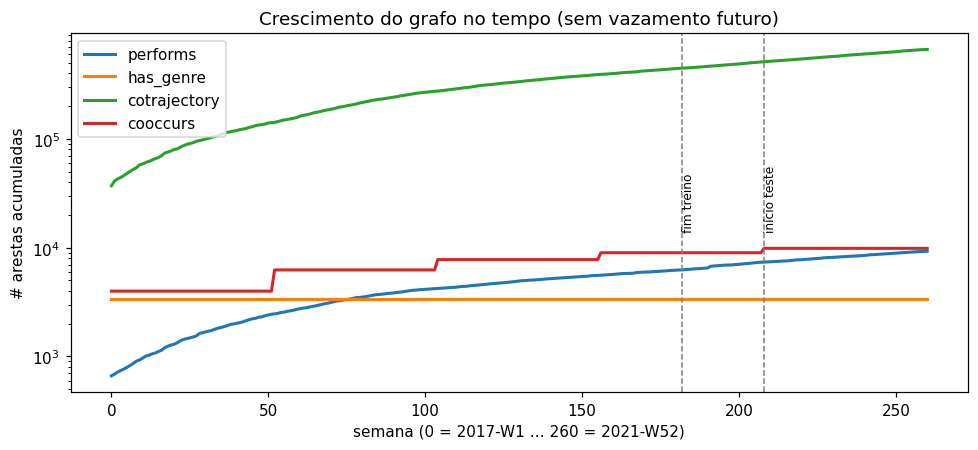

In [9]:
def fsw_of(et):
    s = g[et]
    if getattr(s, "edge_attr", None) is not None:
        return s.edge_attr[:, -1].numpy()
    return s.first_seen_week.numpy()

weeks = np.arange(0, 261)
fig, ax = plt.subplots(figsize=(9, 4.2))
for et in g.edge_types:
    if et[1] == "rev_has_genre":  # mesma curva de has_genre
        continue
    f = fsw_of(et)
    cum = np.array([(f <= w).sum() for w in weeks])
    ax.plot(weeks, cum, label=et[1], lw=2)
for bx, lab in [(182, "fim treino"), (208, "início teste")]:
    ax.axvline(bx, color="gray", ls="--", lw=1); ax.text(bx, ax.get_ylim()[1]*0.02, lab, rotation=90, fontsize=8, va="bottom")
ax.set_xlabel("semana (0 = 2017-W1 … 260 = 2021-W52)"); ax.set_ylabel("# arestas acumuladas")
ax.set_yscale("log"); ax.legend(); ax.set_title("Crescimento do grafo no tempo (sem vazamento futuro)")
plt.tight_layout(); plt.show()

**O mesmo subgrafo crescendo no tempo** — só as co-trajetórias da semente que já
existiam em cada semana `w`:

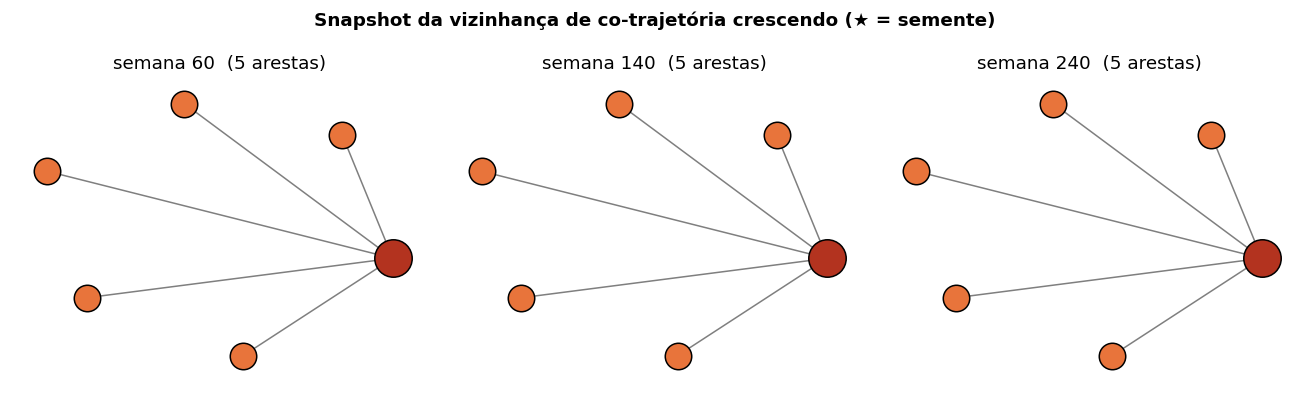

In [10]:
# co-trajetórias incidentes na semente, com sua semana de surgimento
cot_attr = g[("music", "cotrajectory", "music")].edge_attr.numpy()
inc = np.where((cot_ei[0] == seed) | (cot_ei[1] == seed))[0]
pairs = [(cot_ei[0][e], cot_ei[1][e], cot_attr[e, -1]) for e in inc]

snaps = [60, 140, 240]
fig, axes = plt.subplots(1, len(snaps), figsize=(12, 3.6))
nodes_all = set([seed] + [p for e in inc for p in (cot_ei[0][e], cot_ei[1][e])])
H = nx.Graph(); H.add_nodes_from(nodes_all)
lay = nx.spring_layout(H, seed=7, k=1.0)
for ax, wk in zip(axes, snaps):
    Hs = nx.Graph(); Hs.add_node(seed)
    for u, v, f in pairs:
        if f <= wk: Hs.add_edge(int(u), int(v))
    nx.draw_networkx_nodes(Hs, lay, node_color=COL["music"], node_size=300, edgecolors="black", ax=ax)
    nx.draw_networkx_nodes(Hs, lay, nodelist=[seed], node_color="#b3331f", node_size=600, edgecolors="black", ax=ax)
    nx.draw_networkx_edges(Hs, lay, ax=ax, alpha=0.5)
    ax.set_title(f"semana {wk}  ({Hs.number_of_edges()} arestas)"); ax.axis("off")
fig.suptitle("Snapshot da vizinhança de co-trajetória crescendo (★ = semente)", fontweight="bold")
plt.tight_layout(); plt.show()

## 6. Do snapshot ao alvo

### 6a. Agregação semanal (`aggregate_weekly`)

O sinal diário de popularidade `y ∈ [0, 0.5]` é agregado para um alvo **semanal** `y_week`
(média dentro da semana ISO). É esse `y_week` que o modelo prevê.

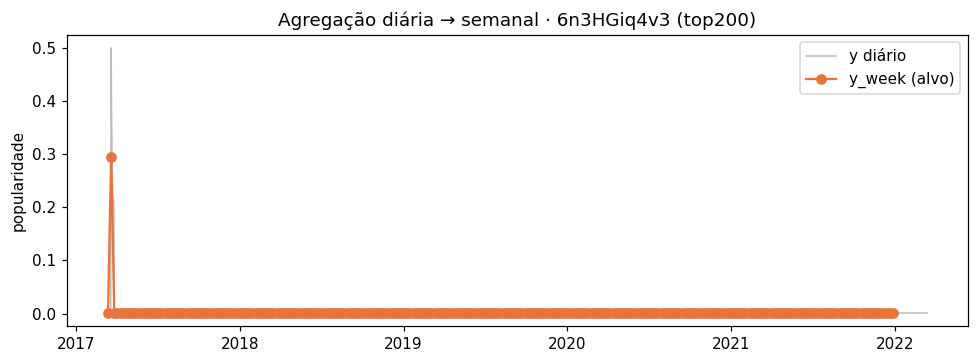

In [11]:
from music_diffusion_gnn.training.dataset import aggregate_weekly, temporal_split, build_samples
from music_diffusion_gnn.training.dataset import TRAIN_END_WEEK, TEST_START_WEEK

weekly = aggregate_weekly(ts)
# uma música ilustrativa: a semente, no chart onde ela mais aparece
sid = idx_to_song[seed]
sub_daily = ts[ts["song_id"] == sid].copy()
chart_pick = sub_daily["chart"].value_counts().idxmax()
sub_daily = sub_daily[sub_daily["chart"] == chart_pick].sort_values("date")
sub_week = weekly[(weekly["song_id"] == sid) & (weekly["chart"] == chart_pick)].sort_values("week")

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(sub_daily["date"], sub_daily["y"], color="#bbb", lw=1, label="y diário")
wk_dates = pd.to_datetime("2017-01-02") + pd.to_timedelta(sub_week["week"] * 7, unit="D")
ax.plot(wk_dates, sub_week["y_week"], "o-", color=COL["music"], label="y_week (alvo)")
ax.set_title(f"Agregação diária → semanal · {sid[:10]} ({chart_pick})")
ax.set_ylabel("popularidade"); ax.legend(); plt.tight_layout(); plt.show()

### 6b. Janela causal + splits temporais

Para prever a semana-alvo `w`, o modelo usa os embeddings das **W semanas anteriores**
`[w-W … w-1]` (com *padding*/máscara antes de a música surgir). Os splits são **por semana**,
sem vazamento: treino ≤ 182, validação 183–207, teste ≥ 208.

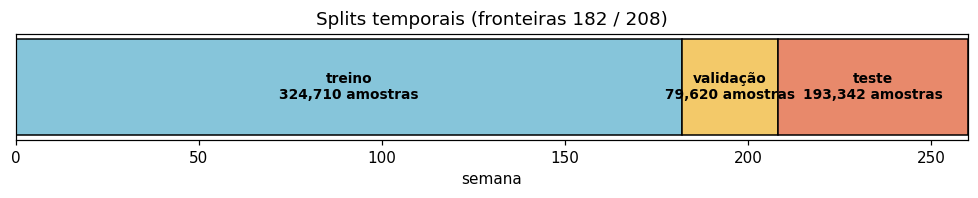

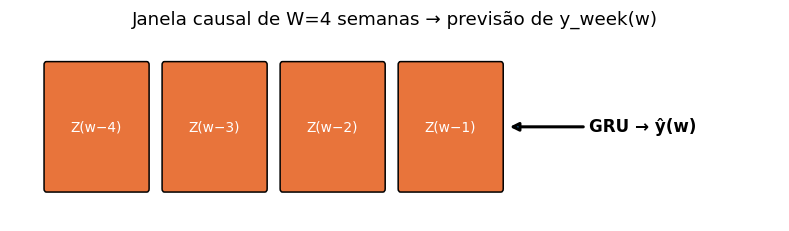

In [12]:
splits = temporal_split(weekly)
fig, ax = plt.subplots(figsize=(9, 1.9))
regions = [(0, TRAIN_END_WEEK, "treino", "#86c5da"),
           (TRAIN_END_WEEK, TEST_START_WEEK, "validação", "#f3c969"),
           (TEST_START_WEEK, 260, "teste", "#e8896b")]
for a, b, lab, c in regions:
    ax.barh(0, b - a, left=a, color=c, ec="black")
    ax.text((a + b) / 2, 0, f"{lab}\n{len(splits['train' if lab=='treino' else 'val' if lab=='validação' else 'test']):,} amostras",
            ha="center", va="center", fontsize=9, fontweight="bold")
ax.set_xlim(0, 260); ax.set_yticks([]); ax.set_xlabel("semana")
ax.set_title("Splits temporais (fronteiras 182 / 208)"); plt.tight_layout(); plt.show()

# diagrama da janela causal (W=4)
W = 4
fig, ax = plt.subplots(figsize=(9, 2.2)); ax.axis("off")
for k in range(W):
    ax.add_patch(FancyBboxPatch((k, 0), 0.85, 0.8, boxstyle="round,pad=0.02", fc=COL["music"], ec="black"))
    ax.text(k + 0.42, 0.4, f"Z(w−{W-k})", ha="center", va="center", color="white", fontsize=9)
ax.annotate("GRU → ŷ(w)", xy=(W - 0.1, 0.4), xytext=(W + 0.6, 0.4), va="center",
            arrowprops=dict(arrowstyle="-|>", lw=2), fontsize=11, fontweight="bold")
ax.set_xlim(-0.3, W + 2.2); ax.set_ylim(-0.2, 1)
ax.set_title(f"Janela causal de W={W} semanas → previsão de y_week(w)"); plt.show()

## 7. A arquitetura, visual

O pipeline completo: cada snapshot semanal vira embeddings por música (HeteroGraphSAGE);
uma janela desses embeddings passa por uma GRU que prevê a popularidade semanal.

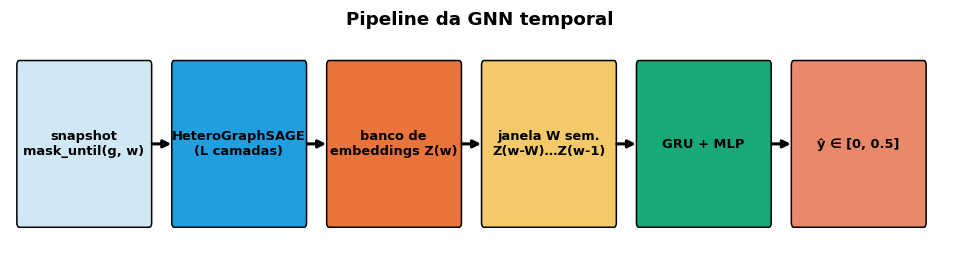

In [13]:
fig, ax = plt.subplots(figsize=(11, 2.6)); ax.axis("off")
stages = [("snapshot\nmask_until(g, w)", "#cfe8f3"),
          ("HeteroGraphSAGE\n(L camadas)", COL["artist"]),
          ("banco de\nembeddings Z(w)", COL["music"]),
          ("janela W sem.\nZ(w-W)…Z(w-1)", "#f3c969"),
          ("GRU + MLP", COL["genre"]),
          ("ŷ ∈ [0, 0.5]", "#e8896b")]
x = 0
for i, (txt, c) in enumerate(stages):
    ax.add_patch(FancyBboxPatch((x, 0), 1.55, 1.0, boxstyle="round,pad=0.03", fc=c, ec="black"))
    ax.text(x + 0.77, 0.5, txt, ha="center", va="center", fontsize=8.5, fontweight="bold")
    if i < len(stages) - 1:
        ax.annotate("", xy=(x + 1.85, 0.5), xytext=(x + 1.55, 0.5), arrowprops=dict(arrowstyle="-|>", lw=2))
    x += 1.85
ax.set_xlim(-0.1, x); ax.set_ylim(-0.2, 1.2)
ax.set_title("Pipeline da GNN temporal", fontweight="bold"); plt.show()

In [14]:
# Contagem real de parâmetros (1 forward na config base W4_h64_l2)
from music_diffusion_gnn.models.diffusion_gnn import MusicDiffusionGNN
model = MusicDiffusionGNN(g.metadata(), hidden=64, layers=2)
with torch.no_grad():
    bank = model.encode_weeks(g, weeks=[208], max_cotraj_edges=30_000)
print(f"Embedding por música: {tuple(bank[208].shape)}")
print(f"Parâmetros (hidden=64, layers=2): {model.count_params():,}")
print("Grid completo varia ~82K (h64) a ~469K (h128, layers=3) parâmetros.")

Embedding por música: (6526, 64)
Parâmetros (hidden=64, layers=2): 82,625
Grid completo varia ~82K (h64) a ~469K (h128, layers=3) parâmetros.


## 8. Resultados preliminares

> O foco da Phase 2 foi **construir e validar o pipeline temporal** de ponta a ponta, sem
> vazamento. O **grid de 24 configurações ainda está em execução**; os números abaixo são
> **preliminares**. A avaliação completa (comparação dupla contra SIR e persistência) é da
> **Phase 3**.

Configs concluídas no grid até agora: 1


,config_str,W,hidden,layers,lr,val_mse,n_params
0,W4_h64_l2_lr1e-03,4,64,2,0.001,0.00387,82625


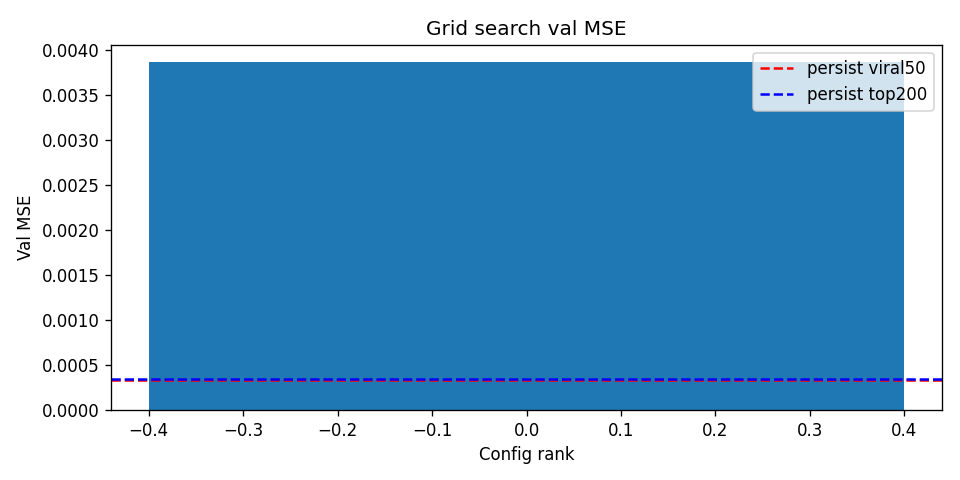

In [15]:
from IPython.display import Image, display
res = ROOT / "results" / "phase2"
gp = res / "grid_results.parquet"
if gp.exists():
    grid = pd.read_parquet(gp)
    print(f"Configs concluídas no grid até agora: {len(grid)}")
    display(grid.sort_values("val_mse")[["config_str", "W", "hidden", "layers", "lr", "val_mse", "n_params"]].head(8))
tc = res / "training_curves.png"
if tc.exists():
    display(Image(filename=str(tc)))

---
### Síntese

Saímos de planilhas diárias de charts e chegamos a um **grafo temporal heterogêneo** que
codifica artista, gênero e co-trajetória de chart, com mascaramento que respeita a flecha do
tempo. Esse grafo alimenta uma GNN (HeteroGraphSAGE + GRU) que prevê a popularidade semanal —
o pipeline está **construído, validado e sem vazamento**. **Próximo passo (Phase 3):** fechar
o grid e fazer a avaliação comparativa honesta contra os baselines.